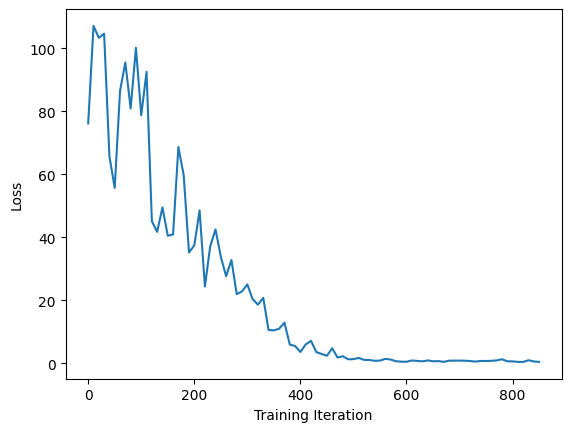

In [1]:
import zarr
import matplotlib.pyplot as plt

def load_metric(name):
    store = zarr.open('mlp_experiment.zarr', mode='r')
    steps = store[f'{name}/steps'][:]
    values = store[f'{name}/values'][:]
    
    # Filter out any unwritten slots (just in case)
    mask = steps != -1
    return steps[mask], values[mask]

# Usage
steps, loss = load_metric('train/loss')
plt.plot(steps, loss)
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.show()

In [2]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def visualize_weights(layer_name):
    store = zarr.open('mlp_experiment.zarr', mode='r')
    # Load the data
    steps = store[f'{layer_name}/steps'][:]
    weights_history = store[f'{layer_name}/values'][:]
    
    # Filter out uninitialized slots
    valid_idx = np.where(steps != -1)[0]
    steps = steps[valid_idx]
    weights_history = weights_history[valid_idx]

    # Create the interactive slider
    @widgets.interact(index=widgets.IntSlider(
        min=0, 
        max=len(steps)-1, 
        step=1, 
        value=0, 
        description='Step Index'
    ))
    def plot_weights(index):
        current_step = steps[index]
        w = weights_history[index]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # 1. Heatmap: See the actual matrix values
        if w.ndim >= 2:
            # If 3D or more, just show a slice of the first two dims
            im = ax1.imshow(w if w.ndim == 2 else w[0], cmap='RdBu', interpolation='nearest')
            fig.colorbar(im, ax=ax1)
            ax1.set_title(f"Weight Matrix at Step {current_step}")
        else:
            ax1.plot(w)
            ax1.set_title(f"Weight Vector at Step {current_step}")

        # 2. Histogram: Watch for Vanishing/Exploding Gradients
        ax2.hist(w.flatten(), bins=50, color='purple', alpha=0.7, edgecolor='black')
        ax2.set_title(f"Distribution (Mean: {w.mean():.4f}, Std: {w.std():.4f})")
        ax2.set_xlabel("Value")
        ax2.set_ylabel("Frequency")
        
        plt.tight_layout()
        plt.show()

# Usage:
# visualize_weights('weights/layer1')
visualize_weights('train/params/hiddenLayer.weight')

interactive(children=(IntSlider(value=0, description='Step Index', max=850), Output()), _dom_classes=('widget-…